# Overview (Donor)

In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

import pandas as pd
import pickle
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sys

from scipy import stats
from importlib.metadata import version

# set seaborn theme
sns.set_theme()

# python modules
import utilities as u
import plot
import custom_impute as ci
import NominalSurvivalRanker

# initializing variables
SEED = 1776

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Seaborn": sns.__version__,
    "Matplot": sys.modules['matplotlib'].__version__,
    # "Sk-Learn": sys.modules['sklearn'].__version__,
    "Scipy": sys.modules['scipy'].__version__,
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# adjust pandas display options to max
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

   Library  Version
0   Python  3.11.13
1   Pandas    2.3.1
2    NumPy    2.3.2
3  Seaborn   0.13.2
4  Matplot   3.10.5
5    Scipy   1.16.1


## Import Data

In [2]:
# import data
df_m = pd.read_pickle("../Data/Donor_Male_Heart_Meds.pkl")
df_f = pd.read_pickle("../Data/Donor_Female_Heart_Meds.pkl")
# display shape
df_m.shape, df_f.shape

((20007, 103), (8319, 103))

## Male

#### User Function(s)

In [3]:
def mean_survival_by_category(data, category_col, duration_col='TransplantSurvivalDay'):
    """
    Returns a DataFrame with each category, its mean survival days, and record counts.
    Warning-free and optimized for categorical columns.
    """
    out = (
        data[[category_col, duration_col]]
        .dropna(subset=[duration_col])
        .groupby(category_col, observed=True)[duration_col]
        .agg(['mean', 'count']) # Perform both calculations at once
        .reset_index()
        .rename(columns={
            "mean": "mean_survival_days",
            "count": "record_count"
        })
    )
    
    # Sort by count or mean to make the report more readable
    return out.sort_values(by="record_count", ascending=False)

In [4]:
# display info
df_m.info(max_cols=df_m.shape[1])

<class 'pandas.core.frame.DataFrame'>
Index: 20007 entries, 0 to 28750
Data columns (total 103 columns):
 #    Column                                Non-Null Count  Dtype   
---   ------                                --------------  -----   
 0    DeceasedRetyped_DON                   20007 non-null  category
 1    AntigenDA1_DON                        20007 non-null  category
 2    AntigenDA2_DON                        20007 non-null  category
 3    AntigenDB1_DON                        20007 non-null  category
 4    AntigenDB2_DON                        20007 non-null  category
 5    AntigenDR1_DON                        20007 non-null  category
 6    AntigenDR2_DON                        20007 non-null  category
 7    Citizenship_DON                       20007 non-null  category
 8    PastCocaineUse_DON                    20007 non-null  category
 9    Age_DON                               20007 non-null  float64 
 10   Ethnicity_DON                         20007 non-null  categor

In [5]:
# Empty DataFrame for record keeping
mapping_df = pd.DataFrame()

#### DeceasedRetyped

In [6]:
# info
features = u.get_feature_info(df_m, 'DeceasedRetyped_DON', cat=False)
# dtype
df_m[features].apply(lambda s: repr(s.dtype))

                     count unique  top   freq
DeceasedRetyped_DON  20007      3  Yes  11899

:::: NaN Count:
DeceasedRetyped_DON    0 



DeceasedRetyped_DON    CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)
dtype: object

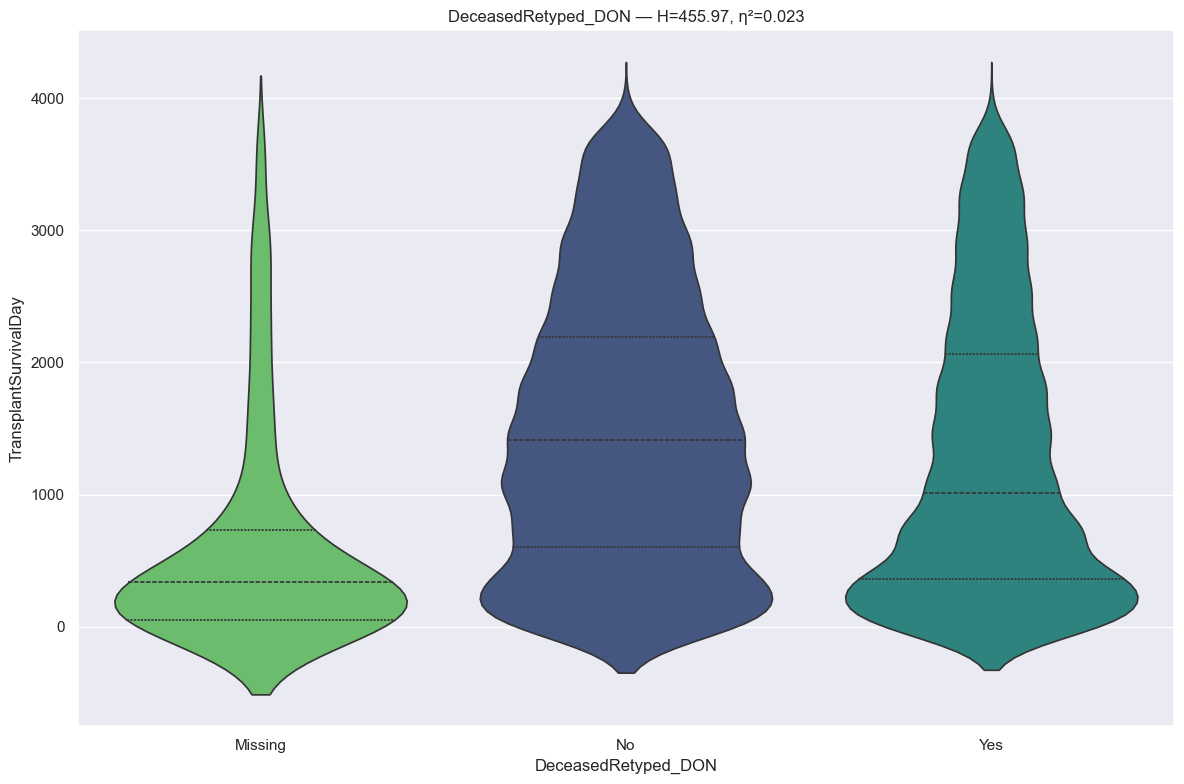

RANKING REPORT: DeceasedRetyped_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing             :    353 records
 * No                  :   7755 records
 * Yes                 :  11899 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 455.9710 | P-value: 9.708720e-100 | Effect η²: 0.0227
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=7.7017e-63 | thr=0.0167 | r= 0.526 | *Sig*
No           vs Yes          | p=4.8613e-54 | thr=0.0167 | r=-0.130 | *Sig*
Missing      vs Yes          | p=5.6914e-40 | thr=0.0167 | r= 0.413 | *Sig*



In [7]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni", # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
)
# initialize variable
results = ranker.fit(df_m, "DeceasedRetyped_DON")
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [8]:
mean_survival_by_category(df_m, "DeceasedRetyped_DON")

,DeceasedRetyped_DON,mean_survival_days,record_count
2,Yes,1253.558702,11899
1,No,1471.829014,7755
0,Missing,604.410765,353


##### **Note:** Statistically significant after Bonferroni and practically meaningful (|r| > 0.10 threshold) and none should be collapsed.

#### Antigen DA1

In [9]:
# info
features = u.get_feature_info(df_m, 'AntigenDA1', cat=False)
# dtype
{col: df_m[col].dtype for col in features}

                count unique top  freq
AntigenDA1_DON  20007     39   2  7936

:::: NaN Count:
AntigenDA1_DON    0 



{'AntigenDA1_DON': CategoricalDtype(categories=['01:01', '01:02', '02:01', '02:02', '02:03', '02:05',
                   '02:06', '03:01', '03:02', '1', '10', '11', '11:01', '2',
                   '23', '24', '24:02', '24:03', '25', '26', '26:01', '28',
                   '29', '29:02', '3', '30', '30:01', '31', '32', '33', '33:03',
                   '34', '34:02', '36', '66', '66:01', '68', '68:02', '69',
                   '74', 'Missing'],
 , ordered=False, categories_dtype=object)}

* Bonferroni/Holm (FWER): These are "perfectionists." They try to ensure there is a 0% chance of even one single mistake (Type I error) across all 741 tests. With 39 categories, these methods become incredibly strict, often failing to find differences even when they exist.
* FDR (Benjamini–Hochberg): This is a "pragmatist." It says, "If I claim 100 pairs are different, I’m okay if $\approx$5 of those claims are wrong." It controls the proportion of errors rather than the existence of a single error.
* We still want to be careful about false positives, but I don’t want to throw away everything here 

In [10]:
mean_survival_by_category(df_m, "AntigenDA1_DON")

,AntigenDA1_DON,mean_survival_days,record_count
12,2,1332.905620,7936
8,1,1335.125644,4465
23,3,1364.078074,2472
14,24,1317.361809,1194
10,11,1360.885584,874
13,23,1308.965007,743
24,30,1305.155357,560
21,29,1290.616046,349
18,26,1332.861789,246
26,31,1342.413613,191


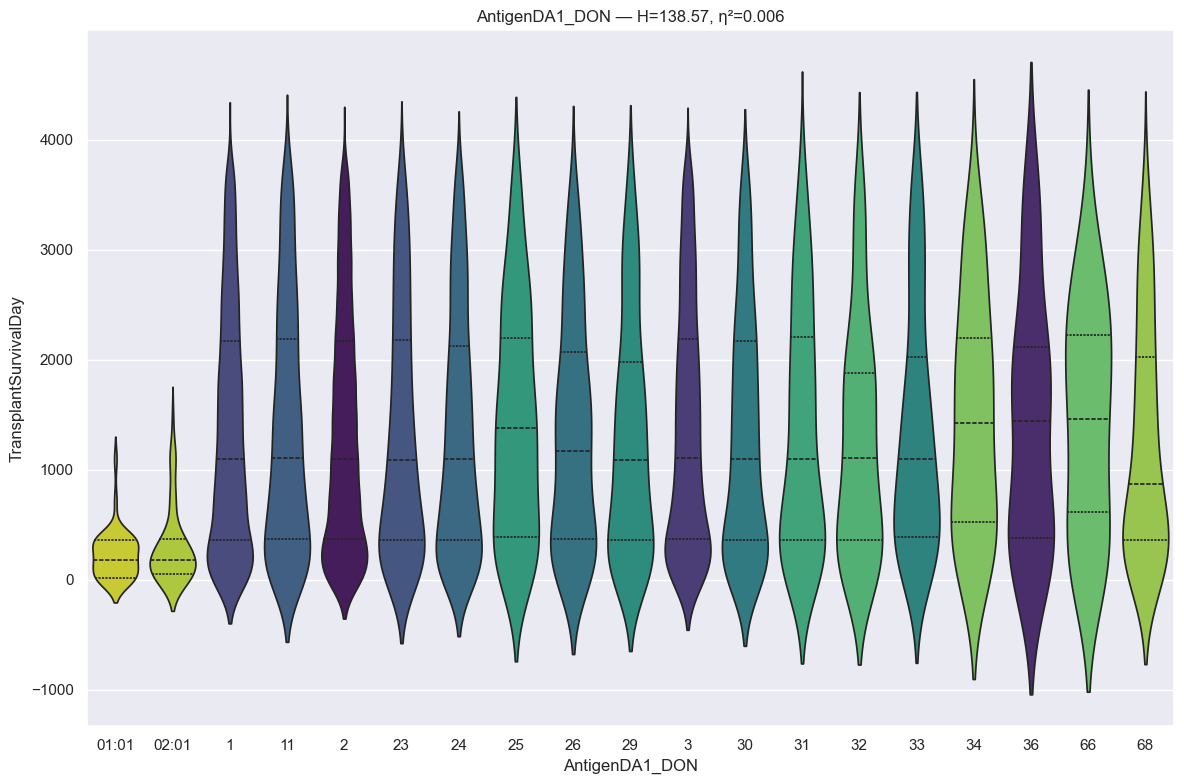

RANKING REPORT: AntigenDA1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 01:01               :     41 records
 * 02:01               :     64 records
 * 1                   :   4465 records
 * 11                  :    874 records
 * 2                   :   7936 records
 * 23                  :    743 records
 * 24                  :   1194 records
 * 25                  :    165 records
 * 26                  :    246 records
 * 29                  :    349 records
 * 3                   :   2472 records
 * 30                  :    560 records
 * 31                  :    191 records
 * 32                  :    142 records
 * 33                  :    182 records
 * 34                  :     66 records
 * 36                  :     49 records
 * 66                  :     33 records
 * 68                  :    148 records
BYPASSED CATEGORIES (n < min_n):
 * 01:02               :      1 records
 * 02:03               :      2 records
 * 02:05               :      3 records
 * 02:06               :  

In [16]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr", # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    suppress_pairwise=True,
)
# initialize variable
results = ranker.fit(df_m, "AntigenDA1_DON")
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [17]:
results['mapping']

{'01:01': 'Group_1',
 '02:01': 'Group_2',
 '1': 'Group_3',
 '11': 'Group_3',
 '2': 'Group_3',
 '23': 'Group_3',
 '24': 'Group_3',
 '25': 'Group_3',
 '26': 'Group_3',
 '29': 'Group_3',
 '3': 'Group_3',
 '30': 'Group_3',
 '31': 'Group_3',
 '32': 'Group_3',
 '33': 'Group_3',
 '34': 'Group_3',
 '36': 'Group_3',
 '66': 'Group_3',
 '68': 'Group_3',
 '01:02': 'Group_4',
 '02:03': 'Group_4',
 '02:05': 'Group_4',
 '02:06': 'Group_4',
 '03:01': 'Group_4',
 '03:02': 'Group_4',
 '10': 'Group_4',
 '11:01': 'Group_4',
 '24:02': 'Group_4',
 '24:03': 'Group_4',
 '26:01': 'Group_4',
 '28': 'Group_4',
 '29:02': 'Group_4',
 '30:01': 'Group_4',
 '33:03': 'Group_4',
 '34:02': 'Group_4',
 '66:01': 'Group_4',
 '68:02': 'Group_4',
 '74': 'Group_4',
 'Missing': 'Group_4'}

In [11]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df_m[features[0] + "_group"] = (
    df_m[features[0]]
    .map(collapse_map)
    .astype("category")
)
# initialize list
remove_cols = features
# mapping DataFrame
mapping_df = pd.concat([pd.DataFrame([u.build_feature_dict(results)]), mapping_df], ignore_index=True)
# sanity check
df_m[features[0] + "_group"].isna().any()

np.False_

#### AntigenDA2

In [12]:
# info
features = u.get_feature_info(df_m, 'AntigenDA2', cat=False)
# dtype
{col: df_m[col].dtype for col in features}

                count unique top  freq
AntigenDA2_DON  20007     46  68  2313

:::: NaN Count:
AntigenDA2_DON    0 



{'AntigenDA2_DON': CategoricalDtype(categories=['0', '01:01', '02:01', '02:03', '02:05', '02:06', '03:01',
                   '1', '10', '11', '11:01', '2', '23', '24', '24:02', '24:03',
                   '25', '26', '26:01', '28', '29', '29:01', '29:02', '3', '30',
                   '30:01', '30:02', '31', '32', '33', '33:01', '33:03', '34',
                   '34:02', '36', '43', '66', '66:01', '66:02', '68', '68:01',
                   '68:02', '69', '74', '80', 'Missing',
                   'No second antigen detected'],
 , ordered=False, categories_dtype=object)}

TOTAL RECORDS (raw): 20,007
TOTAL RECORDS (non-missing TransplantSurvivalDay): 20,007
TOTAL INCLUDED RECORDS (n ≥ 30): 19,818


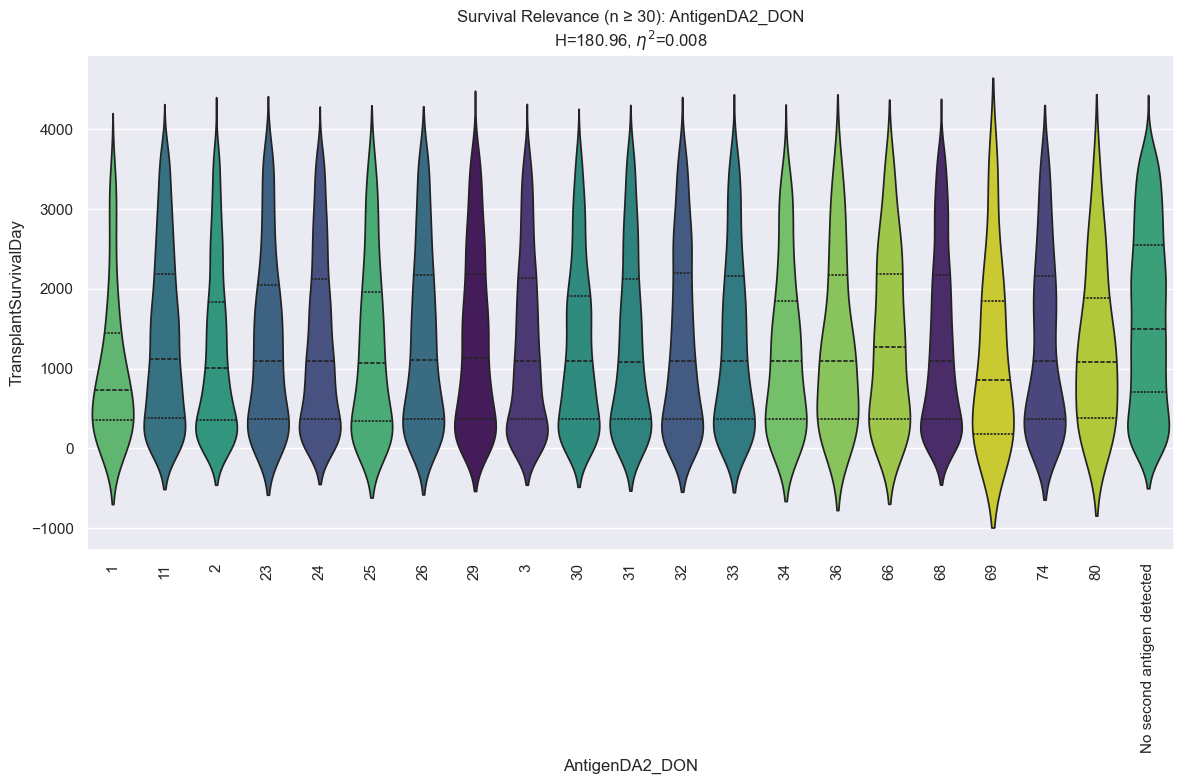

RANKING REPORT: AntigenDA2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 - 1              :    123 records
 - 11             :   1179 records
 - 2              :   1930 records
 - 23             :    657 records
 - 24             :   2205 records
 - 25             :    463 records
 - 26             :    712 records
 - 29             :   1046 records
 - 3              :   2073 records
 - 30             :   1301 records
 - 31             :   1031 records
 - 32             :   1035 records
 - 33             :    881 records
 - 34             :    260 records
 - 36             :    130 records
 - 66             :    242 records
 - 68             :   2313 records
 - 69             :     55 records
 - 74             :    429 records
 - 80             :     68 records
 - No second antigen detected:   1685 records
(Bypassed 25 categories with n < 30)
-----------------------------------------------------------------
Kruskal H: 180.9551
P-value:   6.311394e-28
Effect η²: 0.0081
----------------------------

In [13]:
results=cc.nominal_rank_survival(df_m, 'AntigenDA2_DON', supress=True, rotation=90)

In [14]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df_m[features[0] + "_group"] = (
    df_m[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to list
remove_cols.extend(features)
# mapping DataFrame
mapping_df = pd.concat([pd.DataFrame([u.build_feature_dict(results)]), mapping_df], ignore_index=True)
# sanity check
df_m[features[0] + "_group"].isna().any()

np.False_

####  Antigen DB1

In [15]:
# info
features = u.get_feature_info(df_m, 'AntigenDB1', cat=False)
# dtype
{col: df_m[col].dtype for col in features}

                count unique top  freq
AntigenDB1_DON  20007     76   7  3978

:::: NaN Count:
AntigenDB1_DON    0 



{'AntigenDB1_DON': CategoricalDtype(categories=['07:02', '08:01', '13', '13:02', '14', '14:01', '14:02',
                   '15', '15:01', '15:03', '15:07', '15:10', '15:16', '15:17',
                   '15:18', '18', '27', '27:04', '27:05', '35', '35:01',
                   '35:02', '35:03', '35:08', '35:12', '37', '38', '38:01',
                   '39', '39:01', '39:02', '39:06', '40', '40:01', '40:02',
                   '40:05', '40:06', '41', '41:02', '42', '42:01', '42:02',
                   '44', '44:02', '44:03', '45', '46', '47', '48', '49', '50',
                   '50:01', '51', '51:01', '51:02', '52', '53', '54', '55',
                   '55:01', '56', '56:03', '57', '58', '59', '60', '61', '62',
                   '63', '64', '65', '7', '70', '703', '71', '72', '75', '76',
                   '77', '78', '8', '81', 'Missing'],
 , ordered=False, categories_dtype=object)}

TOTAL RECORDS (raw): 20,007
TOTAL RECORDS (non-missing TransplantSurvivalDay): 20,007
TOTAL INCLUDED RECORDS (n ≥ 30): 19,720


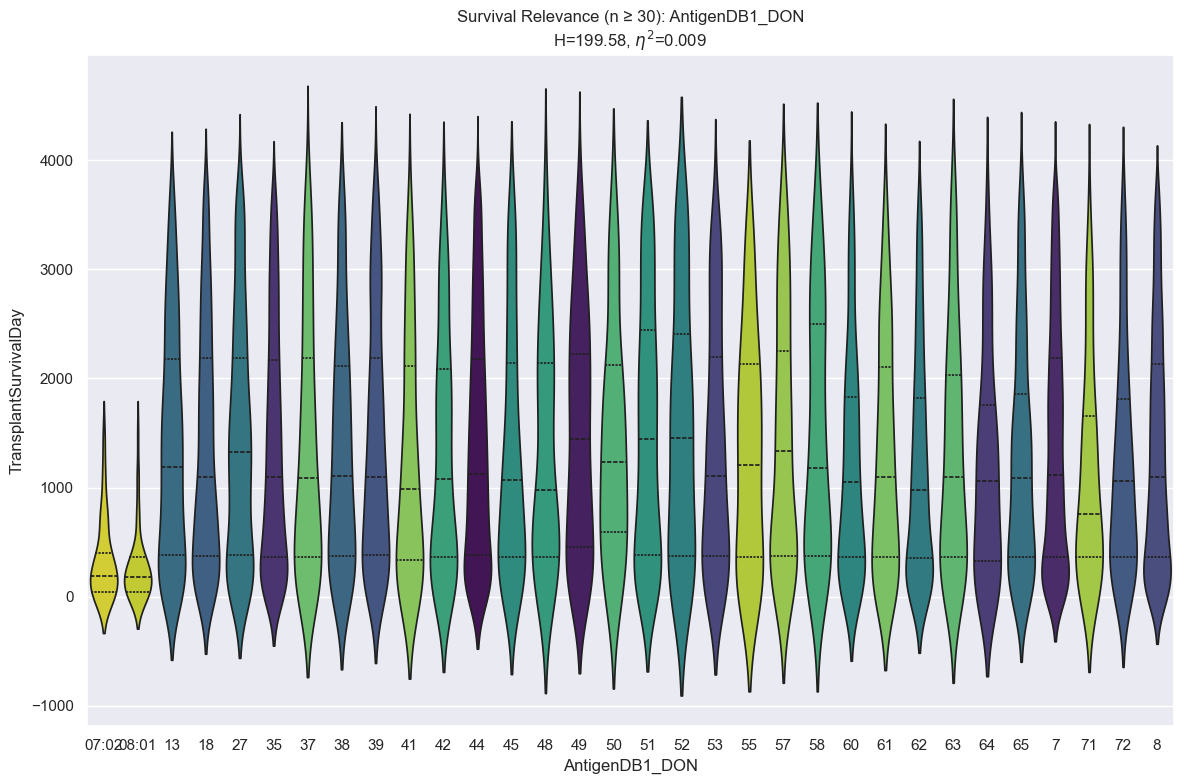

RANKING REPORT: AntigenDB1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 - 07:02          :     54 records
 - 08:01          :     47 records
 - 13             :    601 records
 - 18             :   1101 records
 - 27             :    831 records
 - 35             :   2413 records
 - 37             :    249 records
 - 38             :    308 records
 - 39             :    575 records
 - 41             :    171 records
 - 42             :    272 records
 - 44             :   1766 records
 - 45             :    263 records
 - 48             :     75 records
 - 49             :    261 records
 - 50             :     87 records
 - 51             :    415 records
 - 52             :    113 records
 - 53             :    257 records
 - 55             :     73 records
 - 57             :    192 records
 - 58             :    115 records
 - 60             :    482 records
 - 61             :    267 records
 - 62             :    915 records
 - 63             :    142 records
 - 64             :    139 re

In [16]:
results=cc.nominal_rank_survival(df_m, 'AntigenDB1_DON', supress=True)

In [17]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df_m[features[0] + "_group"] = (
    df_m[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to list
remove_cols.extend(features)
# mapping DataFrame
mapping_df = pd.concat([pd.DataFrame([u.build_feature_dict(results)]), mapping_df], ignore_index=True)
# sanity check
df_m[features[0] + "_group"].isna().any()

np.False_

#### Antigen DB2

In [18]:
# info
features = u.get_feature_info(df_m, 'AntigenDB2', cat=False)
# dtype
{col: df_m[col].dtype for col in features}

                count unique top  freq
AntigenDB2_DON  20007     85  44  2826

:::: NaN Count:
AntigenDB2_DON    0 



{'AntigenDB2_DON': CategoricalDtype(categories=['07:02', '08:01', '12', '13', '13:02', '14', '14:01',
                   '14:02', '15', '15:01', '15:10', '15:16', '15:17', '18',
                   '22', '27', '27:05', '27:08', '35', '35:01', '35:02',
                   '35:03', '35:08', '35:12', '37', '38', '38:01', '39',
                   '39:01', '39:02', '39:05', '39:06', '40', '40:01', '40:02',
                   '40:05', '41', '41:01', '41:02', '42', '42:01', '42:02',
                   '44', '44:02', '44:03', '45', '46', '47', '48', '48:01',
                   '49', '50', '50:01', '51', '51:01', '51:02', '52', '53',
                   '54', '55', '55:01', '56', '56:01', '57', '57:01', '57:03',
                   '58', '59', '60', '61', '62', '63', '64', '65', '67', '7',
                   '70', '71', '72', '73', '75', '76', '77', '78', '8', '81',
                   '82', '82:01', 'Missing', 'No second antigen detected'],
 , ordered=False, categories_dtype=object)}

TOTAL RECORDS (raw): 20,007
TOTAL RECORDS (non-missing TransplantSurvivalDay): 20,007
TOTAL INCLUDED RECORDS (n ≥ 30): 19,661


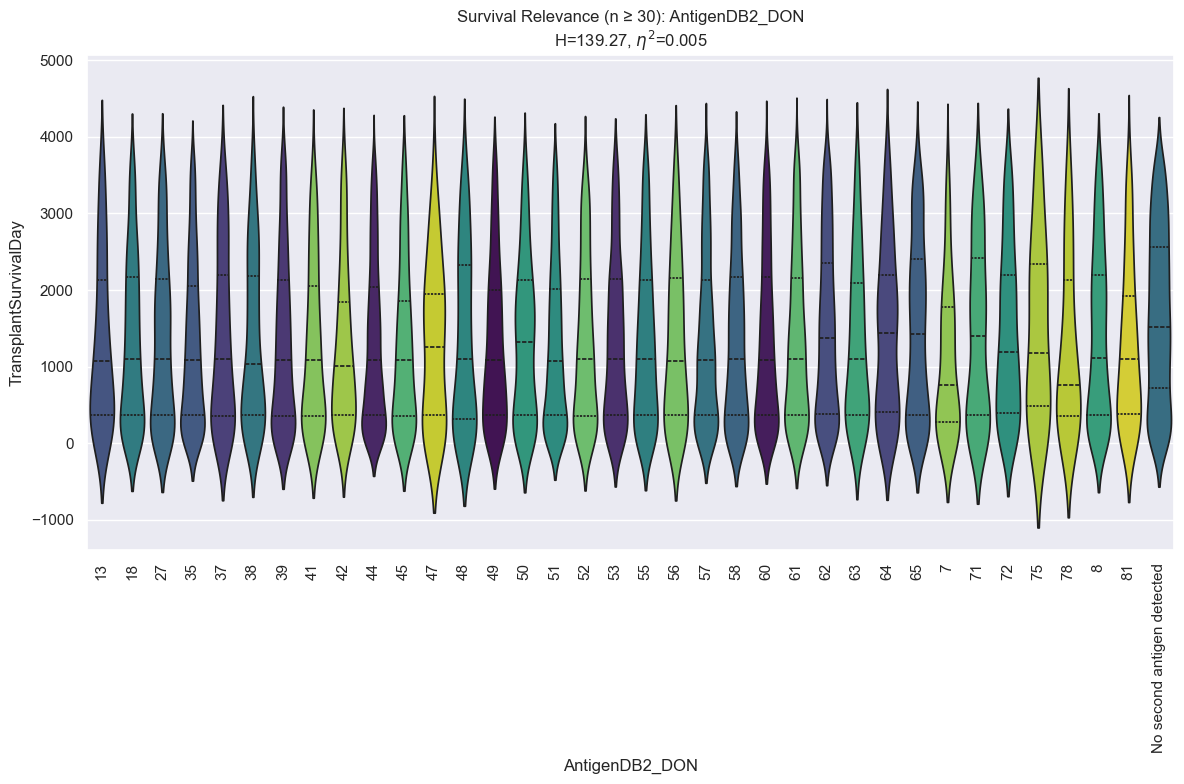

RANKING REPORT: AntigenDB2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 - 13             :    163 records
 - 18             :    467 records
 - 27             :    447 records
 - 35             :   1392 records
 - 37             :    240 records
 - 38             :    280 records
 - 39             :    633 records
 - 41             :    227 records
 - 42             :    218 records
 - 44             :   2826 records
 - 45             :    425 records
 - 47             :     60 records
 - 48             :    167 records
 - 49             :    489 records
 - 50             :    329 records
 - 51             :   1543 records
 - 52             :    447 records
 - 53             :    687 records
 - 55             :    471 records
 - 56             :    177 records
 - 57             :   1183 records
 - 58             :    772 records
 - 60             :   1129 records
 - 61             :    630 records
 - 62             :   1107 records
 - 63             :    184 records
 - 64             :    213 re

In [19]:
results=cc.nominal_rank_survival(df_m, 'AntigenDB2_DON', supress=True, rotation=90)

In [20]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df_m[features[0] + "_group"] = (
    df_m[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to list
remove_cols.extend(features)
# mapping DataFrame
mapping_df = pd.concat([pd.DataFrame([u.build_feature_dict(results)]), mapping_df], ignore_index=True)
# sanity check
df_m[features[0] + "_group"].isna().any()

np.False_

#### Antigen DR1

In [21]:
# info
features = u.get_feature_info(df_m, 'AntigenDR1', cat=False)
# dtype
{col: df_m[col].dtype for col in features}

                count unique top  freq
AntigenDR1_DON  20007     43   4  5012

:::: NaN Count:
AntigenDR1_DON    0 



{'AntigenDR1_DON': CategoricalDtype(categories=['01:01', '01:02', '01:03', '03:01', '03:02', '04:01',
                   '04:02', '04:03', '04:04', '04:05', '04:07', '04:11',
                   '08:01', '08:02', '09:01', '1', '10', '103', '11', '11:01',
                   '11:03', '11:04', '12', '12:01', '13', '13:01', '13:02',
                   '13:03', '13:05', '14', '14:02', '14:04', '14:54', '15',
                   '15:01', '16', '17', '18', '3', '4', '7', '8', '9',
                   'Missing'],
 , ordered=False, categories_dtype=object)}

TOTAL RECORDS (raw): 20,007
TOTAL RECORDS (non-missing TransplantSurvivalDay): 20,007
TOTAL INCLUDED RECORDS (n ≥ 30): 19,874


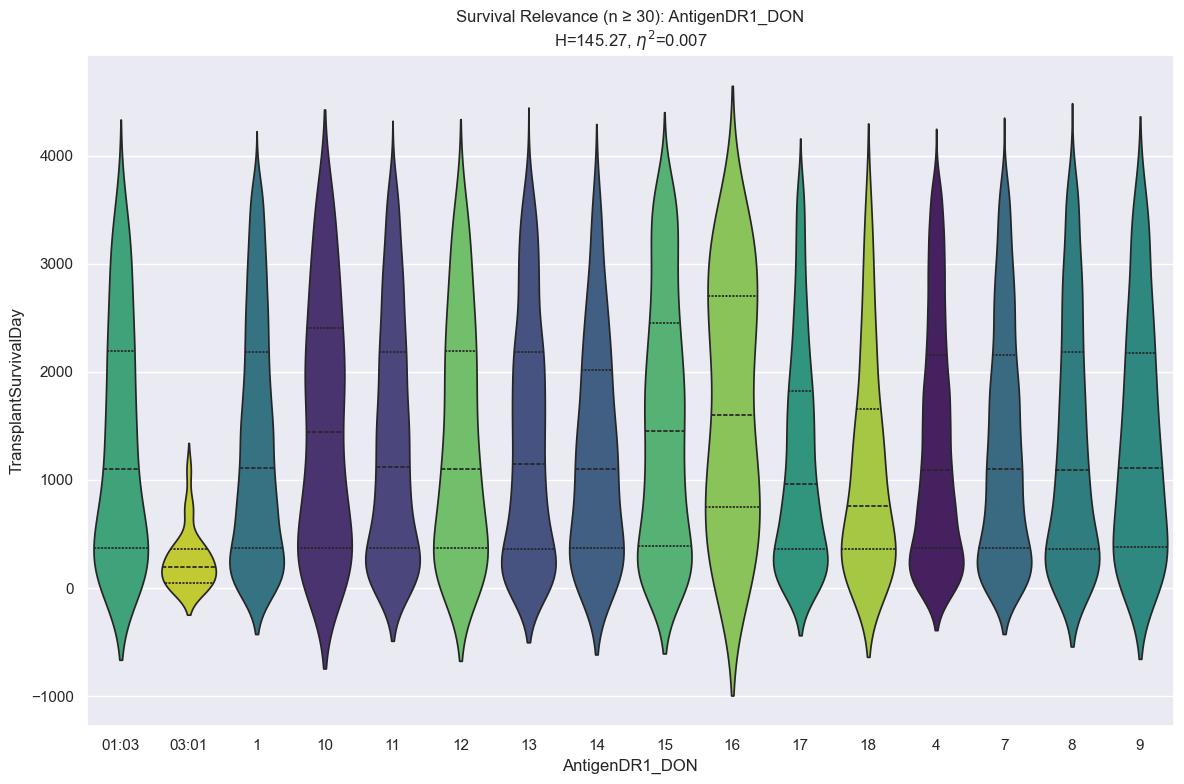

RANKING REPORT: AntigenDR1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 - 01:03          :    344 records
 - 03:01          :     48 records
 - 1              :   3180 records
 - 10             :    244 records
 - 11             :   1590 records
 - 12             :    309 records
 - 13             :   1472 records
 - 14             :    333 records
 - 15             :    757 records
 - 16             :     58 records
 - 17             :   1930 records
 - 18             :    257 records
 - 4              :   5012 records
 - 7              :   2901 records
 - 8              :   1097 records
 - 9              :    342 records
(Bypassed 27 categories with n < 30)
-----------------------------------------------------------------
Kruskal H: 145.2654
P-value:   2.095718e-23
Effect η²: 0.0066
-----------------------------------------------------------------
Pairwise Testing (Bonferroni Alpha: 0.0004)

SKIPPED: Pairwise results are suppressed as per user request.



In [22]:
results=cc.nominal_rank_survival(df_m, 'AntigenDR1_DON' ,supress=True)

In [23]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df_m[features[0] + "_group"] = (
    df_m[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to list
remove_cols.extend(features)
# mapping DataFrame
mapping_df = pd.concat([pd.DataFrame([u.build_feature_dict(results)]), mapping_df], ignore_index=True)
# sanity check
df_m[features[0] + "_group"].isna().any()

np.False_

#### Antigen DR2

In [24]:
# info
features = u.get_feature_info(df_m, 'AntigenDR2', cat=False)
# dtype
{col: df_m[col].dtype for col in features}

                count unique top  freq
AntigenDR2_DON  20007     44  15  4192

:::: NaN Count:
AntigenDR2_DON    0 



{'AntigenDR2_DON': CategoricalDtype(categories=['01:01', '01:03', '03:01', '04:01', '04:04', '04:05',
                   '04:07', '08:01', '08:02', '09:01', '1', '10', '103', '11',
                   '11:01', '11:03', '11:04', '12', '12:01', '12:02', '13',
                   '13:01', '13:02', '13:03', '13:05', '14', '14:01', '14:02',
                   '14:04', '14:06', '14:54', '15', '15:01', '15:02', '15:03',
                   '16', '16:01', '16:02', '17', '18', '3', '4', '5', '7', '8',
                   '9', 'Missing', 'No second antigen detected'],
 , ordered=False, categories_dtype=object)}

TOTAL RECORDS (raw): 20,007
TOTAL RECORDS (non-missing TransplantSurvivalDay): 20,007
TOTAL INCLUDED RECORDS (n ≥ 30): 19,832


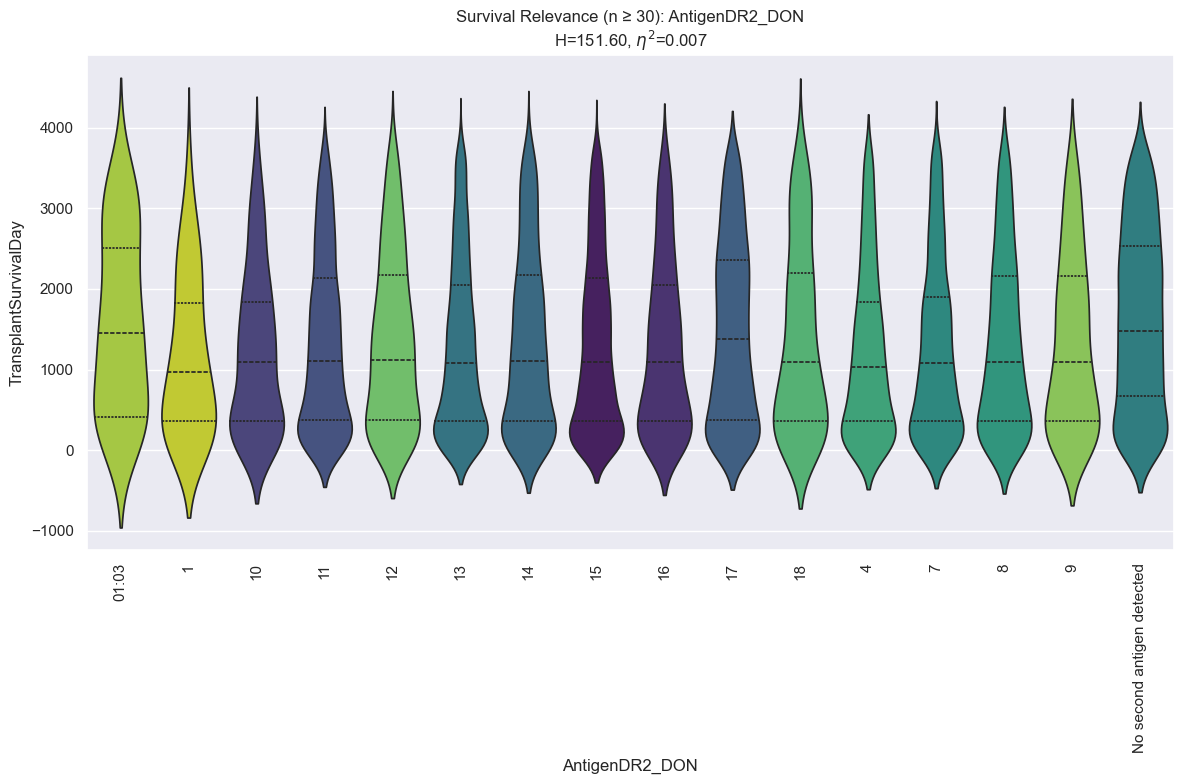

RANKING REPORT: AntigenDR2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 - 01:03          :     59 records
 - 1              :     66 records
 - 10             :    236 records
 - 11             :   2007 records
 - 12             :    530 records
 - 13             :   3124 records
 - 14             :   1146 records
 - 15             :   4192 records
 - 16             :    712 records
 - 17             :   1833 records
 - 18             :    291 records
 - 4              :   1370 records
 - 7              :   1724 records
 - 8              :    920 records
 - 9              :    279 records
 - No second antigen detected:   1343 records
(Bypassed 28 categories with n < 30)
-----------------------------------------------------------------
Kruskal H: 151.5964
P-value:   1.162191e-24
Effect η²: 0.0069
-----------------------------------------------------------------
Pairwise Testing (Bonferroni Alpha: 0.0004)

SKIPPED: Pairwise results are suppressed as per user request.



In [25]:
results=cc.nominal_rank_survival(df_m, 'AntigenDR2_DON' ,supress=True, rotation=90)

In [26]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df_m[features[0] + "_group"] = (
    df_m[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to list
remove_cols.extend(features)
# mapping DataFrame
mapping_df = pd.concat([pd.DataFrame([u.build_feature_dict(results)]), mapping_df], ignore_index=True)
# sanity check
df_m[features[0] + "_group"].isna().any()

np.False_

#### Citizenship

In [27]:
# info
features = u.get_feature_info(df_m, 'Citizenship', cat=False)
# dtype
{col: df_m[col].dtype for col in features}

                 count unique         top   freq
Citizenship_DON  20007      7  US Citizen  18000

:::: NaN Count:
Citizenship_DON    0 



{'Citizenship_DON': CategoricalDtype(categories=['Missing', 'NON-RESIDENT ALIEN',
                   'Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant',
                   'Non-US Citizen/US Resident', 'RESIDENT ALIEN', 'US Citizen',
                   'Unknown'],
 , ordered=False, categories_dtype=object)}

TOTAL RECORDS (raw): 20,007
TOTAL RECORDS (non-missing TransplantSurvivalDay): 20,007
TOTAL INCLUDED RECORDS (n ≥ 30): 19,968


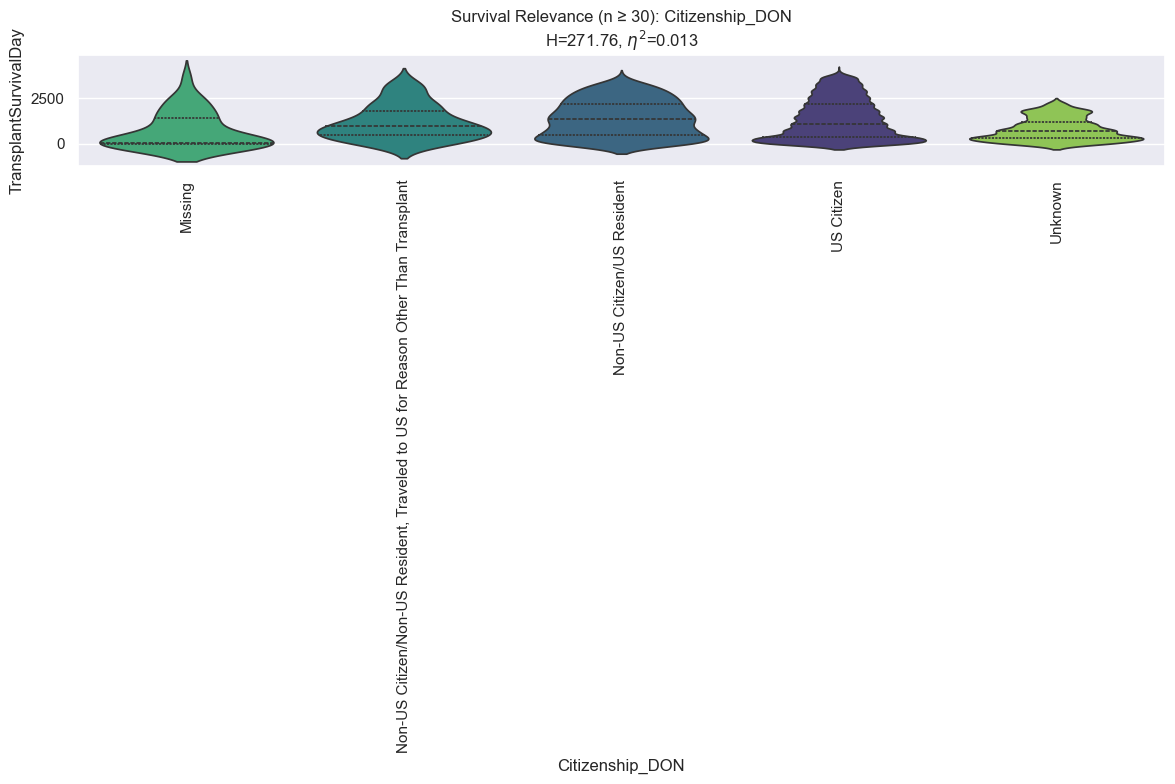

RANKING REPORT: Citizenship_DON (n ≥ 30)
INCLUDED CATEGORIES:
 - Missing        :     36 records
 - Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant:     74 records
 - Non-US Citizen/US Resident:    668 records
 - US Citizen     :  18000 records
 - Unknown        :   1190 records
(Bypassed 2 categories with n < 30)
-----------------------------------------------------------------
Kruskal H: 271.7595
P-value:   1.332039e-57
Effect η²: 0.0134
-----------------------------------------------------------------
Pairwise Testing (Bonferroni Alpha: 0.0050)
Missing      vs Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant | p=1.4299e-03 | r= 0.376 | *Sig*
Missing      vs Non-US Citizen/US Resident | p=4.7037e-06 | r= 0.453 | *Sig*
Missing      vs US Citizen   | p=8.1596e-06 | r= 0.430 | *Sig*
Missing      vs Unknown      | p=9.0230e-03 | r= 0.255 | Not Sig
Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant

In [28]:
results=cc.nominal_rank_survival(df_m, 'Citizenship_DON' , rotation=90)

In [29]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df_m[features[0] + "_group"] = (
    df_m[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to list
remove_cols.extend(features)
# mapping DataFrame
mapping_df = pd.concat([pd.DataFrame([u.build_feature_dict(results)]), mapping_df], ignore_index=True)
# sanity check
df_m[features[0] + "_group"].isna().any()

np.False_

#### Past Cocaine Use

In [30]:
# info
features = u.get_feature_info(df_m, 'PastCocaineUse_DON', cat=False)
# dtype
{col: df_m[col].dtype for col in features}

                    count unique top   freq
PastCocaineUse_DON  20007      4  No  14941

:::: NaN Count:
PastCocaineUse_DON    0 



{'PastCocaineUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

TOTAL RECORDS (raw): 20,007
TOTAL RECORDS (non-missing TransplantSurvivalDay): 20,007
TOTAL INCLUDED RECORDS (n ≥ 30): 20,007


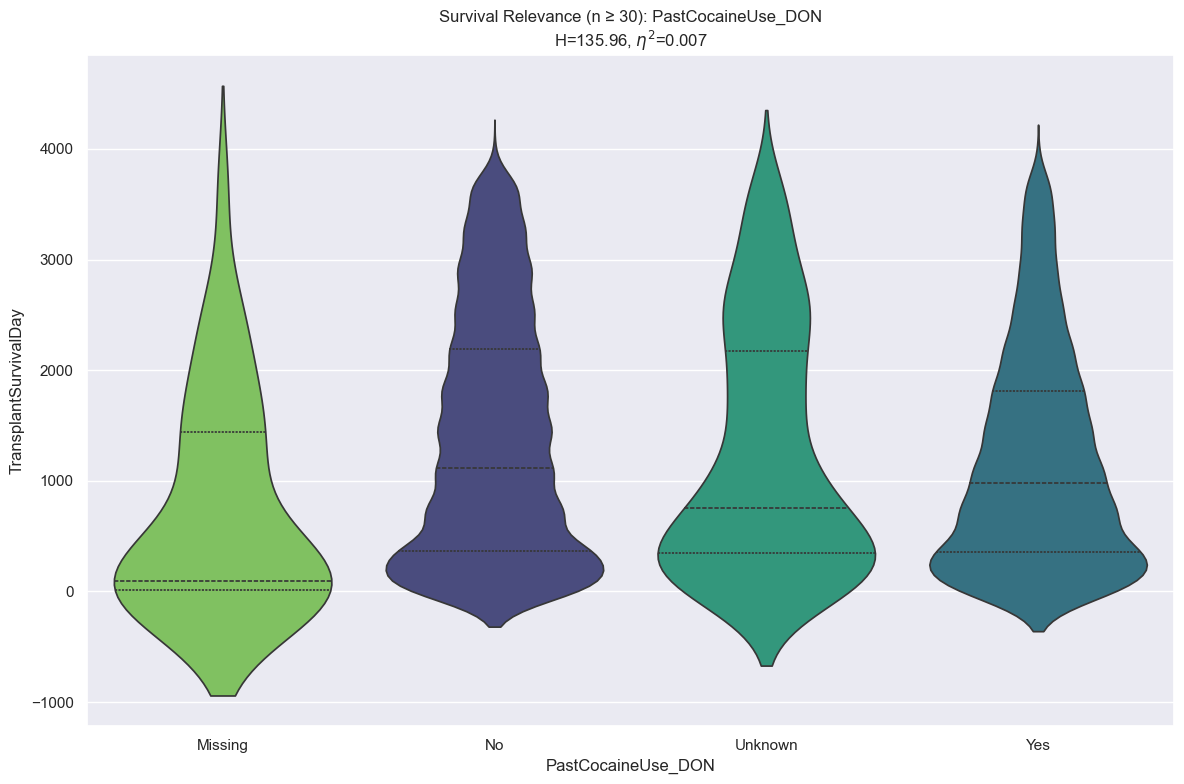

RANKING REPORT: PastCocaineUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 - Missing        :     38 records
 - No             :  14941 records
 - Unknown        :    383 records
 - Yes            :   4645 records
-----------------------------------------------------------------
Kruskal H: 135.9621
P-value:   2.805587e-29
Effect η²: 0.0066
-----------------------------------------------------------------
Pairwise Testing (Bonferroni Alpha: 0.0083)
Missing      vs No           | p=4.2176e-06 | r= 0.431 | *Sig*
Missing      vs Unknown      | p=1.7079e-04 | r= 0.370 | *Sig*
Missing      vs Yes          | p=9.5442e-05 | r= 0.367 | *Sig*
No           vs Unknown      | p=4.2647e-03 | r=-0.085 | *Sig*
No           vs Yes          | p=2.8975e-26 | r=-0.103 | *Sig*
Unknown      vs Yes          | p=8.6167e-01 | r=-0.005 | Not Sig



In [31]:
results=cc.nominal_rank_survival(df_m, 'PastCocaineUse_DON')

##### Note:** Unknown and Yes behave the same in survival terms.

In [32]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df_m[features[0] + "_group"] = (
    df_m[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to list
remove_cols.extend(features)
# mapping DataFrame
mapping_df = pd.concat([pd.DataFrame([u.build_feature_dict(results)]), mapping_df], ignore_index=True)
# sanity check
df_m[features[0] + "_group"].isna().any()

np.False_

#### Ethnicity

In [33]:
# info
features = u.get_feature_info(df_m, 'Ethnicity', cat=False)
# dtype
{col: df_m[col].dtype for col in features}

               count unique                  top   freq
Ethnicity_DON  20007      7  White, Non-Hispanic  12428

:::: NaN Count:
Ethnicity_DON    0 



{'Ethnicity_DON': CategoricalDtype(categories=['Amer Ind/Alaska Native', 'Asian', 'Black', 'Hispanic',
                   'Multiracial', 'Native Hawaiian/other Pacific Islander',
                   'White, Non-Hispanic'],
 , ordered=False, categories_dtype=object)}

TOTAL RECORDS (raw): 20,007
TOTAL RECORDS (non-missing TransplantSurvivalDay): 20,007
TOTAL INCLUDED RECORDS (n ≥ 30): 20,007


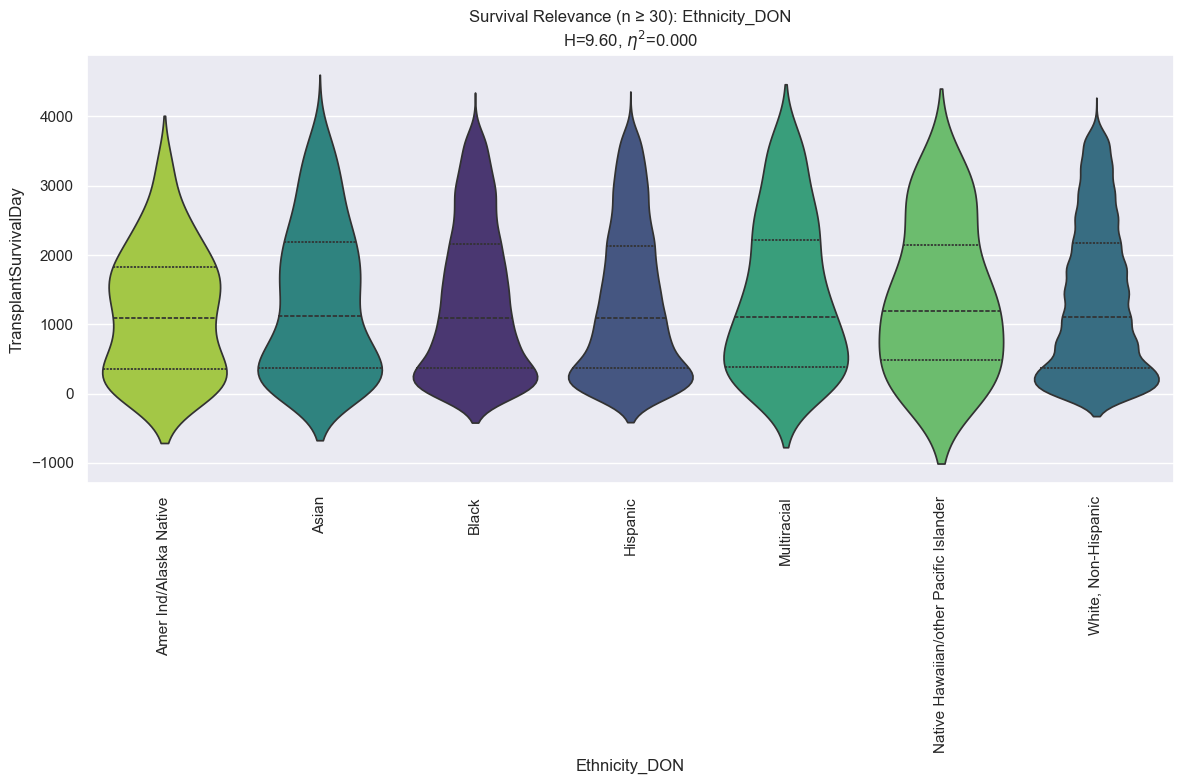

RANKING REPORT: Ethnicity_DON (n ≥ 30)
INCLUDED CATEGORIES:
 - Amer Ind/Alaska Native:    102 records
 - Asian          :    324 records
 - Black          :   3314 records
 - Hispanic       :   3629 records
 - Multiracial    :    172 records
 - Native Hawaiian/other Pacific Islander:     38 records
 - White, Non-Hispanic:  12428 records
-----------------------------------------------------------------
Kruskal H: 9.6015
P-value:   1.424703e-01
Effect η²: 0.0002
-----------------------------------------------------------------

::::: WARNING: Non‑significant Global Kruskal–Wallis across all categories. :::::

Pairwise Testing (Bonferroni Alpha: 0.0024)
Amer Ind/Alaska Native vs Asian        | p=2.1555e-01 | r= 0.081 | Not Sig
Amer Ind/Alaska Native vs Black        | p=3.0701e-01 | r= 0.059 | Not Sig
Amer Ind/Alaska Native vs Hispanic     | p=4.9297e-01 | r= 0.040 | Not Sig
Amer Ind/Alaska Native vs Multiracial  | p=1.1066e-01 | r= 0.115 | Not Sig
Amer Ind/Alaska Native vs Native Hawaiian

In [34]:
results=cc.nominal_rank_survival(df_m, 'Ethnicity_DON', rotation=90)

##### **Note:** Non‑significant Global Kruskal–Wallis across all categories suggests there is no evidence that any ethnicity category differs in survival distribution, confirmed by the pairwise testing, therefore no splitting is justified.

#### Hepatitis B Core Antibody

In [35]:
# info
features = u.get_feature_info(df_m, 'Hepatitis_B_CoreAntibody', cat=False)
# dtype
{col: df_m[col].dtype for col in features}

                              count unique       top   freq
Hepatitis_B_CoreAntibody_DON  20007      5  Negative  19595

:::: NaN Count:
Hepatitis_B_CoreAntibody_DON    0 



{'Hepatitis_B_CoreAntibody_DON': CategoricalDtype(categories=['Indeterminate', 'Negative', 'Not Done', 'Pending',
                   'Positive'],
 , ordered=False, categories_dtype=object)}

TOTAL RECORDS (raw): 20,007
TOTAL RECORDS (non-missing TransplantSurvivalDay): 20,007
TOTAL INCLUDED RECORDS (n ≥ 30): 19,995


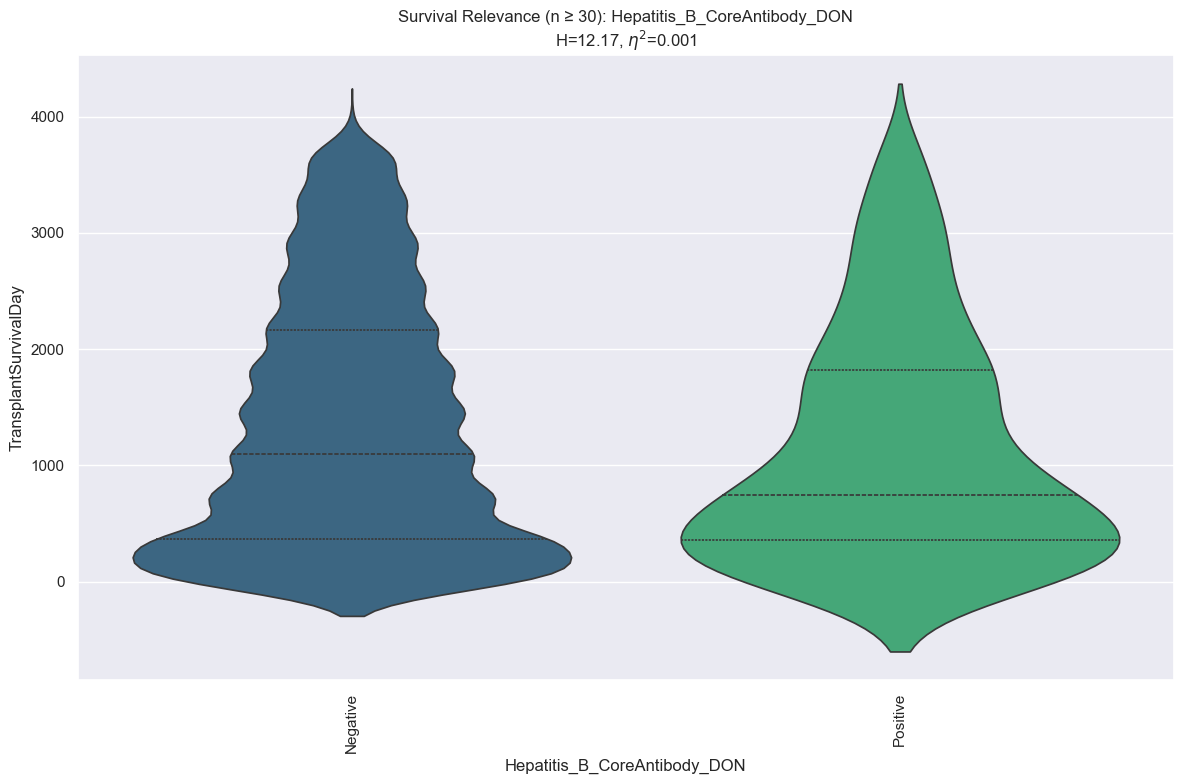

RANKING REPORT: Hepatitis_B_CoreAntibody_DON (n ≥ 30)
INCLUDED CATEGORIES:
 - Negative       :  19595 records
 - Positive       :    400 records
(Bypassed 3 categories with n < 30)
-----------------------------------------------------------------
Kruskal H: 12.1671
P-value:   4.863923e-04
Effect η²: 0.0006
-----------------------------------------------------------------
Pairwise Testing (Bonferroni Alpha: 0.0500)
Negative     vs Positive     | p=4.8640e-04 | r=-0.102 | *Sig*



In [36]:
results=cc.nominal_rank_survival(df_m, 'Hepatitis_B_CoreAntibody_DON', rotation=90)

#### Surface Antigen HEP B

In [37]:
# info
features = u.get_feature_info(df_m, 'SurfaceAntigenHEP_B', cat=False)
# dtype
{col: df_m[col].dtype for col in features}

                         count unique       top   freq
SurfaceAntigenHEP_B_DON  20007      5  Negative  19971

:::: NaN Count:
SurfaceAntigenHEP_B_DON    0 



{'SurfaceAntigenHEP_B_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Positive'],
 , ordered=False, categories_dtype=object)}

In [38]:
results=cc.nominal_rank_survival(df_m, 'SurfaceAntigenHEP_B_DON', supress=True, rotation=90)

TOTAL RECORDS (raw): 20,007
TOTAL RECORDS (non-missing TransplantSurvivalDay): 20,007
TOTAL INCLUDED RECORDS (n ≥ 30): 19,971

::::: SKIPPED: Only one category with n ≥ 30 for SurfaceAntigenHEP_B_DON :::::


In [39]:
mean_survival_by_category(df_m, "SurfaceAntigenHEP_B_DON")

,SurfaceAntigenHEP_B_DON,mean_survival_days,record_count
2,Negative,1326.824946,19971
4,Positive,801.500000,14
1,Missing,1316.454545,11
3,Not Done,1592.000000,9
0,Indeterminate,2717.500000,2


##### **Note:** We will perform a manual Binning in which the Positive, Missing, Not Done, and Indeterminate groups are grouped into a single category called `Non-Negative` (Total $n=36$). This would give us just enough data to meet your $n \ge 30$ threshold and compare `Negative` vs. `Non-Negative`.

In [40]:
# mapping
mapping = {'Positive': 'Non-Negative',
           'Missing': 'Non-Negative',
           'Not Done': 'Non-Negative',
           'Indeterminate': 'Non-Negative'
          }
# map the change
df_m.SurfaceAntigenHEP_B_DON = df_m.SurfaceAntigenHEP_B_DON.map(mapping).fillna(df_m.SurfaceAntigenHEP_B_DON)
# sanity check
mean_survival_by_category(df_m, "SurfaceAntigenHEP_B_DON")

,SurfaceAntigenHEP_B_DON,mean_survival_days,record_count
0,Negative,1326.824946,19971
1,Non-Negative,1262.916667,36


TOTAL RECORDS (raw): 20,007
TOTAL RECORDS (non-missing TransplantSurvivalDay): 20,007
TOTAL INCLUDED RECORDS (n ≥ 30): 20,007


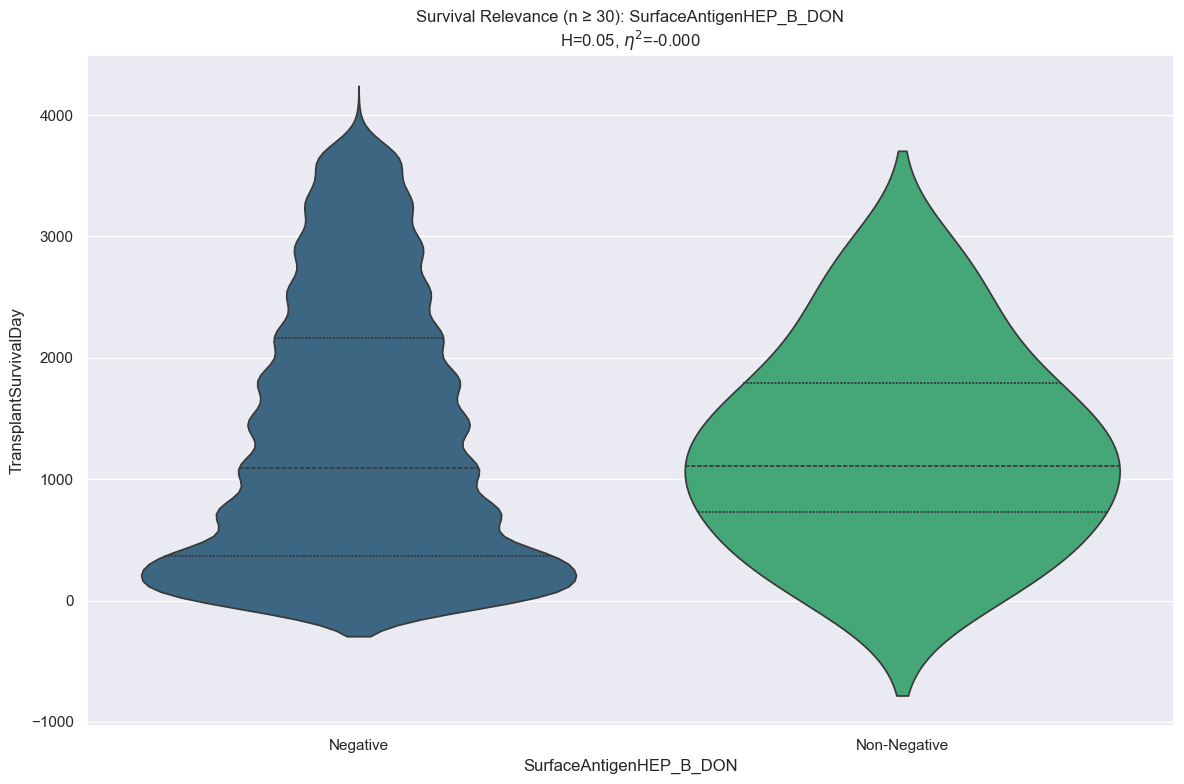

RANKING REPORT: SurfaceAntigenHEP_B_DON (n ≥ 30)
INCLUDED CATEGORIES:
 - Negative       :  19971 records
 - Non-Negative   :     36 records
-----------------------------------------------------------------
Kruskal H: 0.0483
P-value:   8.261188e-01
Effect η²: -0.0000
-----------------------------------------------------------------

::::: WARNING: Non‑significant Global Kruskal–Wallis across all categories. :::::

Pairwise Testing (Bonferroni Alpha: 0.0500)
Negative     vs Non-Negative | p=8.2613e-01 | r= 0.021 | Not Sig



In [41]:
results=cc.nominal_rank_survival(df_m, 'SurfaceAntigenHEP_B_DON')

In [42]:
mean_survival_by_category(df_m, "SurfaceAntigenHEP_B_DON")

,SurfaceAntigenHEP_B_DON,mean_survival_days,record_count
0,Negative,1326.824946,19971
1,Non-Negative,1262.916667,36


In [43]:
# The survival distributions for Negative and Non‑Negative are statistically indistinguishable.
remove_cols.extend(features)

#### Blood Group

In [44]:
# info
features = u.get_feature_info(df_m, 'BloodGroup', cat=False)
# dtype
{col: df_m[col].dtype for col in features}

                count unique top   freq
BloodGroup_DON  20007      8   O  10018

:::: NaN Count:
BloodGroup_DON    0 



{'BloodGroup_DON': CategoricalDtype(categories=['A', 'A1', 'A1B', 'A2', 'A2B', 'AB', 'B', 'O'], ordered=False, categories_dtype=object)}

TOTAL RECORDS (raw): 20,007
TOTAL RECORDS (non-missing TransplantSurvivalDay): 20,007
TOTAL INCLUDED RECORDS (n ≥ 30): 20,007


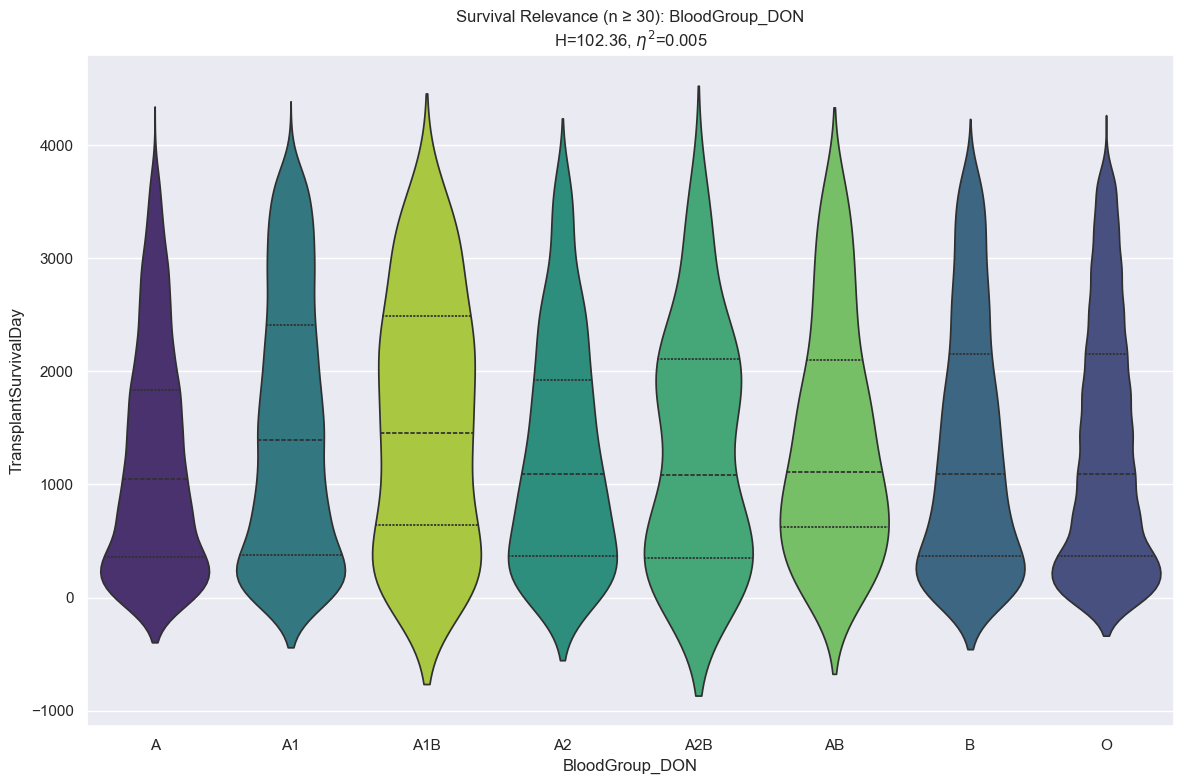

RANKING REPORT: BloodGroup_DON (n ≥ 30)
INCLUDED CATEGORIES:
 - A              :   3040 records
 - A1             :   3539 records
 - A1B            :    194 records
 - A2             :    606 records
 - A2B            :     74 records
 - AB             :    242 records
 - B              :   2294 records
 - O              :  10018 records
-----------------------------------------------------------------
Kruskal H: 102.3577
P-value:   3.513755e-19
Effect η²: 0.0048
-----------------------------------------------------------------
Pairwise Testing (Bonferroni Alpha: 0.0018)
A            vs A1           | p=9.7019e-21 | r= 0.133 | *Sig*
A            vs A1B          | p=1.9995e-05 | r= 0.182 | *Sig*
A            vs A2           | p=7.8727e-02 | r= 0.045 | Not Sig
A            vs A2B          | p=4.7958e-01 | r= 0.048 | Not Sig
A            vs AB           | p=3.2281e-03 | r= 0.114 | Not Sig
A            vs B            | p=3.9764e-04 | r= 0.057 | *Sig*
A            vs O            | p=2.73

In [45]:
results=cc.nominal_rank_survival(df_m, 'BloodGroup_DON')

In [46]:
mean_survival_by_category(df_m, "BloodGroup_DON")

,BloodGroup_DON,mean_survival_days,record_count
7,O,1310.498004,10018
1,A1,1478.598474,3539
0,A,1198.469737,3040
6,B,1322.562772,2294
3,A2,1271.775578,606
5,AB,1390.615702,242
2,A1B,1554.958763,194
4,A2B,1296.797297,74


In [47]:
# Blood Group has an extremely weak, noisy, and inconsistent signal, and we will remove the feature
remove_cols.extend(features)

#### Heavy Alcohol Use

In [48]:
# info
features = u.get_feature_info(df_m, 'HeavyAlcoholUse_DON', cat=False)
# dtype
{col: df_m[col].dtype for col in features}

                     count unique top   freq
HeavyAlcoholUse_DON  20007      4  No  15661

:::: NaN Count:
HeavyAlcoholUse_DON    0 



{'HeavyAlcoholUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

TOTAL RECORDS (raw): 20,007
TOTAL RECORDS (non-missing TransplantSurvivalDay): 20,007
TOTAL INCLUDED RECORDS (n ≥ 30): 19,997


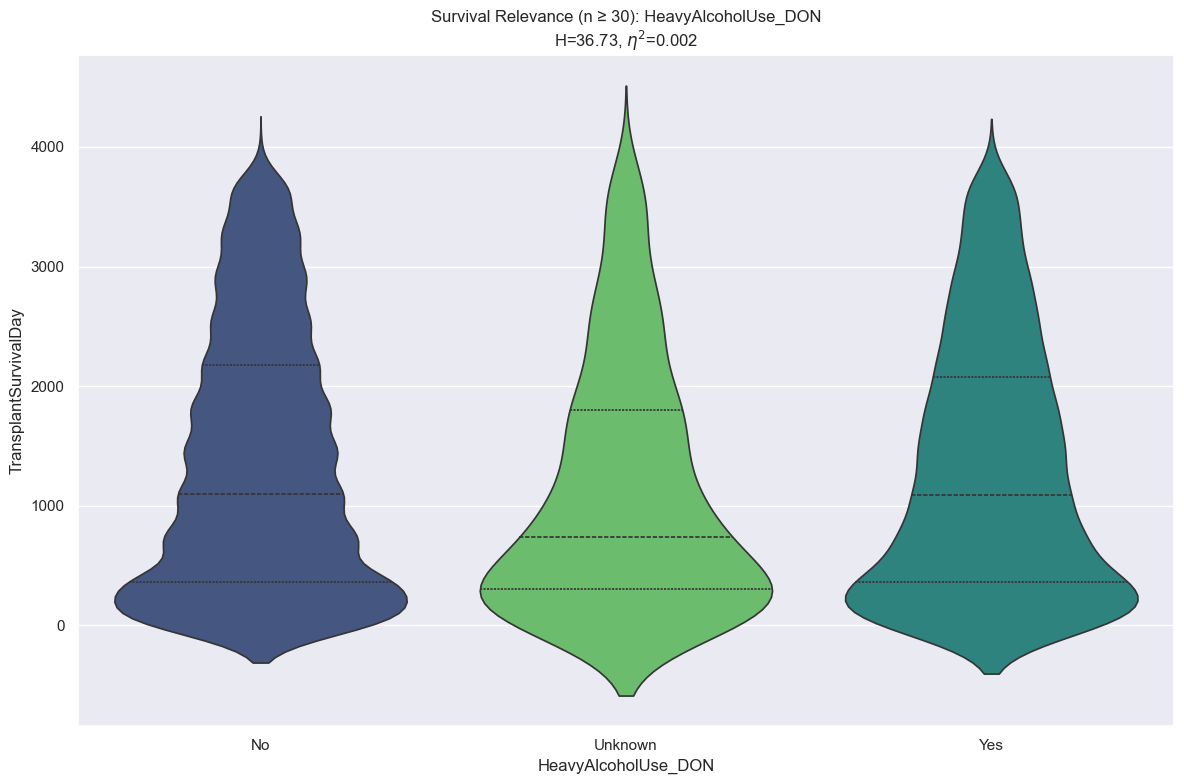

RANKING REPORT: HeavyAlcoholUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 - No             :  15661 records
 - Unknown        :    513 records
 - Yes            :   3823 records
(Bypassed 1 categories with n < 30)
-----------------------------------------------------------------
Kruskal H: 36.7291
P-value:   1.057741e-08
Effect η²: 0.0017
-----------------------------------------------------------------
Pairwise Testing (Bonferroni Alpha: 0.0167)
No           vs Unknown      | p=4.9971e-07 | r=-0.130 | *Sig*
No           vs Yes          | p=1.6486e-04 | r=-0.039 | *Sig*
Unknown      vs Yes          | p=7.5035e-04 | r= 0.092 | *Sig*



In [49]:
results=cc.nominal_rank_survival(df_m, 'HeavyAlcoholUse_DON')

In [50]:
mean_survival_by_category(df_m, "HeavyAlcoholUse_DON")

,HeavyAlcoholUse_DON,mean_survival_days,record_count
1,No,1346.692868,15661
3,Yes,1273.254512,3823
2,Unknown,1114.514620,513
0,Missing,1353.100000,10


In [51]:
# Collapse Missing into No, since mean survival is nearly identical
# mapping
mapping = {'Missing': 'No'}
# map the change
df_m.HeavyAlcoholUse_DON = df_m.HeavyAlcoholUse_DON.map(mapping).fillna(df_m.HeavyAlcoholUse_DON)
# sanity check
mean_survival_by_category(df_m, "HeavyAlcoholUse_DON")

,HeavyAlcoholUse_DON,mean_survival_days,record_count
0,No,1346.696956,15671
2,Yes,1273.254512,3823
1,Unknown,1114.514620,513


#### Gender

In [ ]:
remove_cols.extend(['Gender_DON'])

#### Residency State

In [54]:
# info
features = u.get_feature_info(df_m, 'ResidencyState', cat=False)
# dtype
{col: df_m[col].dtype for col in features}

                    count unique top  freq
ResidencyState_DON  20007     54  CA  2183

:::: NaN Count:
ResidencyState_DON    0 



{'ResidencyState_DON': CategoricalDtype(categories=['AK', 'AL', 'AR', 'AS', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE',
                   'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA',
                   'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND',
                   'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA',
                   'PR', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA',
                   'WI', 'WV', 'WY', 'XX', 'ZZ'],
 , ordered=False, categories_dtype=object)}

TOTAL RECORDS (raw): 20,007
TOTAL RECORDS (non-missing TransplantSurvivalDay): 20,007
TOTAL INCLUDED RECORDS (n ≥ 30): 19,938


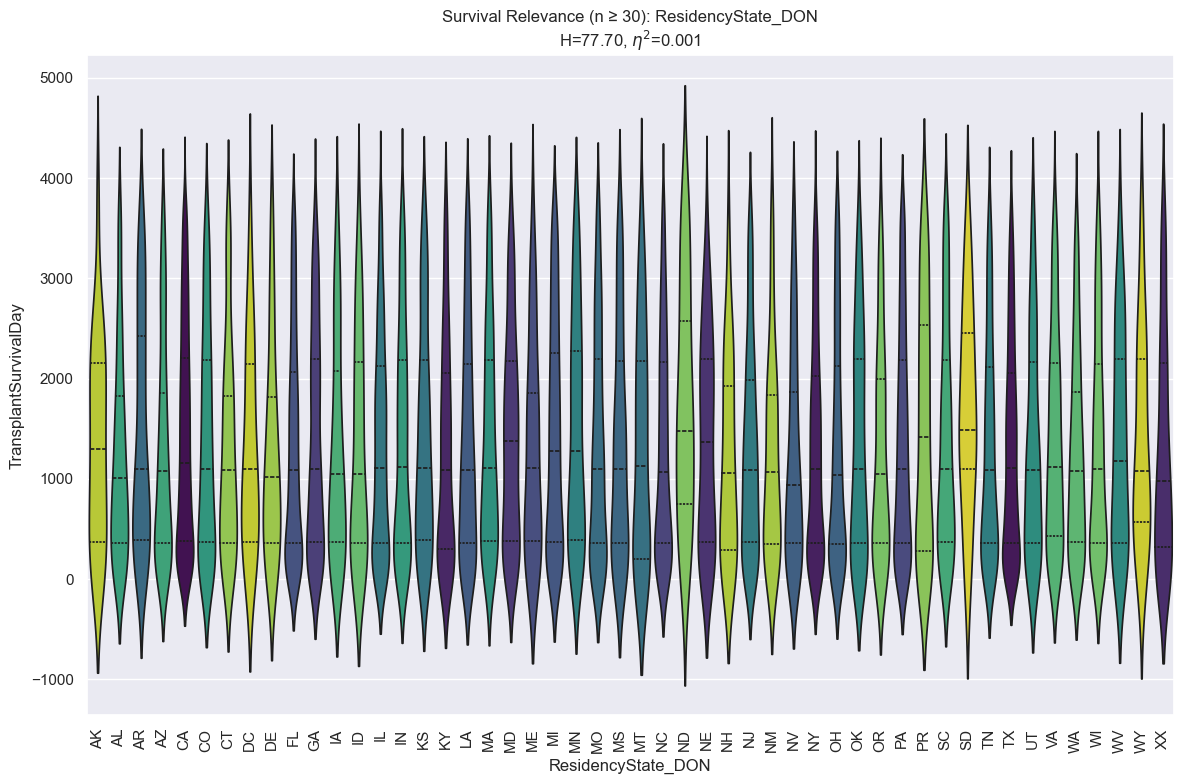

RANKING REPORT: ResidencyState_DON (n ≥ 30)
INCLUDED CATEGORIES:
 - AK             :     47 records
 - AL             :    282 records
 - AR             :    202 records
 - AZ             :    488 records
 - CA             :   2183 records
 - CO             :    336 records
 - CT             :    193 records
 - DC             :     37 records
 - DE             :     99 records
 - FL             :   1276 records
 - GA             :    630 records
 - IA             :    154 records
 - ID             :     94 records
 - IL             :    776 records
 - IN             :    495 records
 - KS             :    260 records
 - KY             :    289 records
 - LA             :    399 records
 - MA             :    329 records
 - MD             :    379 records
 - ME             :     85 records
 - MI             :    605 records
 - MN             :    237 records
 - MO             :    509 records
 - MS             :    188 records
 - MT             :     67 records
 - NC             :    68

In [55]:
results=cc.nominal_rank_survival(df_m, 'ResidencyState_DON', supress=True, rotation=90)

In [58]:
results['mapping']

{'AK': 'Group_1',
 'AL': 'Group_2',
 'AR': 'Group_3',
 'AZ': 'Group_4',
 'CA': 'Group_5',
 'CO': 'Group_6',
 'CT': 'Group_7',
 'DC': 'Group_8',
 'DE': 'Group_9',
 'FL': 'Group_10',
 'GA': 'Group_11',
 'IA': 'Group_12',
 'ID': 'Group_13',
 'IL': 'Group_14',
 'IN': 'Group_15',
 'KS': 'Group_16',
 'KY': 'Group_17',
 'LA': 'Group_18',
 'MA': 'Group_19',
 'MD': 'Group_20',
 'ME': 'Group_21',
 'MI': 'Group_22',
 'MN': 'Group_23',
 'MO': 'Group_24',
 'MS': 'Group_25',
 'MT': 'Group_26',
 'NC': 'Group_27',
 'ND': 'Group_28',
 'NE': 'Group_29',
 'NH': 'Group_30',
 'NJ': 'Group_31',
 'NM': 'Group_32',
 'NV': 'Group_33',
 'NY': 'Group_34',
 'OH': 'Group_35',
 'OK': 'Group_36',
 'OR': 'Group_37',
 'PA': 'Group_38',
 'PR': 'Group_39',
 'SC': 'Group_40',
 'SD': 'Group_41',
 'TN': 'Group_42',
 'TX': 'Group_43',
 'UT': 'Group_44',
 'VA': 'Group_45',
 'WA': 'Group_46',
 'WI': 'Group_47',
 'WV': 'Group_48',
 'WY': 'Group_49',
 'XX': 'Group_50',
 'HI': 'Group_51',
 'RI': 'Group_51',
 'VT': 'Group_51',
 '

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df_m[features[0] + "_group"] = (
    df_m[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to list
remove_cols.extend(features)
# sanity check
df_m[features[0] + "_group"].isna().any()

In [ ]:
# mapping DataFrame
mapping_df = pd.concat([pd.DataFrame([u.build_feature_dict(results)]), mapping_df], ignore_index=True)
mapping_df

In [ ]:
import importlib
importlib.reload(cc)

In [34]:
# display info
df_m.info(max_cols=df_m.shape[1])

<class 'pandas.core.frame.DataFrame'>
Index: 20007 entries, 0 to 28750
Data columns (total 111 columns):
 #    Column                                Non-Null Count  Dtype   
---   ------                                --------------  -----   
 0    DeceasedRetyped_DON                   20007 non-null  category
 1    AntigenDA1_DON                        20007 non-null  category
 2    AntigenDA2_DON                        20007 non-null  category
 3    AntigenDB1_DON                        20007 non-null  category
 4    AntigenDB2_DON                        20007 non-null  category
 5    AntigenDR1_DON                        20007 non-null  category
 6    AntigenDR2_DON                        20007 non-null  category
 7    Citizenship_DON                       20007 non-null  category
 8    PastCocaineUse_DON                    20007 non-null  category
 9    Age_DON                               20007 non-null  float64 
 10   Ethnicity_DON                         20007 non-null  categor